<a href="https://colab.research.google.com/github/pyrenaaaaaa/Emotion-Aware-Companion/blob/text/Final_GoEmotions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install PyTorch and Transformers
!pip install torch torchvision torchaudio transformers datasets pandas scikit-learn emoji nlpaug textattack accelerate evaluate -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 44.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 55.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Imports

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import re
import emoji
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from datasets import Dataset
from transformers import AutoTokenizer, RobertaForSequenceClassification, AdamW
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import warnings
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, TensorDataset
from transformers import AdamW
from sklearn.utils import resample

warnings.filterwarnings("ignore")

# Check PyTorch Version & GPU
print("✅ PyTorch Version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using Device: {device}")

✅ PyTorch Version: 2.6.0+cu124
✅ Using Device: cuda


# Define Paths & Load Dataset

In [2]:
# Define dataset path
goemotions_path = "/content/drive/MyDrive/EmotionCompanion/datasets/text/go_emotions_dataset.csv"

# Load GoEmotions dataset
goemotions_data = pd.read_csv(goemotions_path)
print(f"Loaded GoEmotions dataset with {len(goemotions_data)} samples.")

Loaded GoEmotions dataset with 211225 samples.


# Data Preprocessing

In [3]:
# Define emotions
emotions = ['anger', 'fear', 'joy', 'sadness', 'love']

# Keep only the required columns
filtered_columns = ['text'] + [col for col in emotions if col in goemotions_data.columns]
goemotions_data = goemotions_data[filtered_columns]

# Remove rows without any assigned emotion
goemotions_data = goemotions_data[goemotions_data[emotions].sum(axis=1) > 0].reset_index(drop=True)

# Display dataset sample
print(goemotions_data.head())

                                                text  anger  fear  joy  \
0                                    That game hurt.      0     0    0   
1                                 Man I love reddit.      0     0    0   
2  So happy for [NAME]. So sad he's not here. Ima...      0     0    1   
3  I just came home, what the fuck is this lineup...      0     0    0   
4  By far the coolest thing I've seen on this thr...      0     0    1   

   sadness  love  
0        1     0  
1        0     1  
2        1     0  
3        0     1  
4        0     0  


# Handle Class Imbalance using SMOTE & Resampling

In [4]:
# Compute class weights
class_counts = goemotions_data[emotions].sum(axis=0)
total_count = class_counts.sum()
class_weights = (1 / class_counts) * (total_count / len(class_counts))
class_weight_dict = {i: class_weights.iloc[i] for i in range(len(class_weights))}

# Oversample minority classes
max_class_size = max(class_counts)
balanced_dfs = []
for emotion in emotions:
    df = goemotions_data[goemotions_data[emotion] == 1]
    if len(df) < max_class_size:
        df = resample(df, replace=True, n_samples=max_class_size, random_state=42)
    balanced_dfs.append(df)

# Combine into final dataset
goemotions_balanced = pd.concat(balanced_dfs).reset_index(drop=True)
print(f"✅ Balanced dataset size: {len(goemotions_balanced)}")

✅ Balanced dataset size: 40955


# Text Preprocessing

In [5]:
# Define preprocessing functions
def preprocess_text(text):
    text = re.sub(r'\d+', '<NUM>', text)
    text = re.sub(r'http\S+', '<URL>', text)
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing
goemotions_balanced["cleaned_text"] = goemotions_balanced["text"].apply(preprocess_text)

# Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    goemotions_balanced["cleaned_text"], goemotions_balanced[emotions], test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

print(f"📊 Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

📊 Train: 29487, Validation: 3277, Test: 8191


# Tokenization with RoBERTa

In [7]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("roberta-base", use_fast=True)

# Function to tokenize text
def tokenize_texts(texts, max_length=128):
    return tokenizer(
        list(texts), max_length=max_length, padding="max_length", truncation=True, return_tensors="pt"
    )

# Tokenize datasets
X_train_tokens = tokenize_texts(X_train)
X_val_tokens = tokenize_texts(X_val)
X_test_tokens = tokenize_texts(X_test)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

# Convert Labels to TensorFlow Format

In [8]:
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Create PyTorch DataLoader

In [9]:
# Function to create DataLoader
# def create_dataloader(X_tokens, y_labels, batch_size=16):
#     dataset = TensorDataset(X_tokens['input_ids'], X_tokens['attention_mask'], y_labels)
#     return DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Create DataLoaders
# train_loader = create_dataloader(X_train_tokens, y_train_tensor)
# val_loader = create_dataloader(X_val_tokens, y_val_tensor)
# test_loader = create_dataloader(X_test_tokens, y_test_tensor)

# Function to create DataLoader
def create_dataloader(X_tokens, y_labels, batch_size=16):
    # Convert tokenized outputs to PyTorch tensors
    input_ids = torch.tensor(X_tokens['input_ids'], dtype=torch.long)
    attention_mask = torch.tensor(X_tokens['attention_mask'], dtype=torch.long)

    # Ensure y_labels are also tensors
    labels = torch.tensor(y_labels, dtype=torch.float32)

    # Create TensorDataset
    dataset = TensorDataset(input_ids, attention_mask, labels)

    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

train_loader = create_dataloader(X_train_tokens, y_train.values)
val_loader = create_dataloader(X_val_tokens, y_val.values)
test_loader = create_dataloader(X_test_tokens, y_test.values)

# Load RoBERTa Model

In [10]:
model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=5)
model.to(device)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

# Define Optimizer & Loss

In [11]:
# optimizer = AdamW(model.parameters(), lr=3e-5)
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
loss_fn = torch.nn.BCEWithLogitsLoss()

# Train Model

In [12]:
# ✅ Define Key Variables
num_epochs = 3
batch_size = 16
learning_rate = 3e-5
patience = 2  # Early stopping patience
step_size = 1  # LR scheduler step size
gamma = 0.9  # LR scheduler decay factor
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# print(f"✅ Variables Set. Training on: {device}")

In [13]:
# Clear GPU Memory Before Training
torch.cuda.empty_cache()

# Initialize Loss & Accuracy Tracking
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

# Learning Rate Scheduler
scheduler = StepLR(optimizer, step_size=1, gamma=0.9)  # Reduce LR by 10% per epoch

best_val_loss = float("inf")  # Track the best validation loss
patience = 2  # Number of epochs to wait before stopping
counter = 0  # Counter to track worsening epochs

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct_train = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]", leave=True)

    for batch in train_bar:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(outputs.logits) > 0.5).float()
        correct_train += (preds == labels).sum().item()
        total_train += labels.numel()

        train_bar.set_postfix({"Loss": f"{loss.item():.4f}"})

    avg_train_loss = total_loss / len(train_loader)
    train_accuracy = correct_train / total_train
    train_loss_history.append(avg_train_loss)
    train_acc_history.append(train_accuracy)

    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]", leave=True)

    with torch.no_grad():
        for batch in val_bar:
            input_ids, attention_mask, labels = [x.to(device) for x in batch]
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            val_loss += loss.item()
            preds = (torch.sigmoid(outputs.logits) > 0.5).float()
            correct_val += (preds == labels).sum().item()
            total_val += labels.numel()

            val_bar.set_postfix({"Val Loss": f"{loss.item():.4f}"})

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = correct_val / total_val
    val_loss_history.append(avg_val_loss)
    val_acc_history.append(val_accuracy)

    print(f"\n📊 Epoch {epoch+1} Summary: Train Loss = {avg_train_loss:.4f}, Train Acc = {train_accuracy:.4f}, Val Loss = {avg_val_loss:.4f}, Val Acc = {val_accuracy:.4f}")

    scheduler.step()  # Apply learning rate decay

    # ✅ EARLY STOPPING LOGIC
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0  # Reset counter if validation loss improves
    else:
        counter += 1  # Increase counter if validation loss worsens
        if counter >= patience:
            print(f"\n🚨 Early stopping triggered after {epoch+1} epochs.")
            break  # Stop training

# Save Model After Training
torch.save(model.state_dict(), "best_model.pth")
print("Model saved successfully as 'best_model.pth'!")

Epoch 1/3 [Validation]: 100%|██████████| 205/205 [00:20<00:00,  9.95it/s, Val Loss=0.2555]



📊 Epoch 1 Summary: Train Loss = 0.2529, Train Acc = 0.9028, Val Loss = 0.2040, Val Acc = 0.9263


Epoch 2/3 [Validation]: 100%|██████████| 205/205 [00:20<00:00,  9.96it/s, Val Loss=0.1018]



📊 Epoch 2 Summary: Train Loss = 0.1779, Train Acc = 0.9348, Val Loss = 0.1835, Val Acc = 0.9345


Epoch 3/3 [Validation]: 100%|██████████| 205/205 [00:20<00:00,  9.94it/s, Val Loss=0.0536]



📊 Epoch 3 Summary: Train Loss = 0.1421, Train Acc = 0.9492, Val Loss = 0.1769, Val Acc = 0.9388
Model saved successfully as 'best_model.pth'!


# Evaluate Model Performance


📊 **Final Evaluation Results**
✅ Accuracy: 0.8132
✅ F1-Score (Micro): 0.8643
✅ F1-Score (Macro): 0.8638


📊 **Classification Report:**
              precision    recall  f1-score   support

       anger     0.8719    0.8664    0.8691      1767
        fear     0.8619    0.9258    0.8927      1685
         joy     0.8653    0.8074    0.8354      1750
     sadness     0.8772    0.8003    0.8370      1768
        love     0.8624    0.9083    0.8847      1766

   micro avg     0.8675    0.8611    0.8643      8736
   macro avg     0.8677    0.8617    0.8638      8736
weighted avg     0.8678    0.8611    0.8636      8736
 samples avg     0.8718    0.8731    0.8659      8736



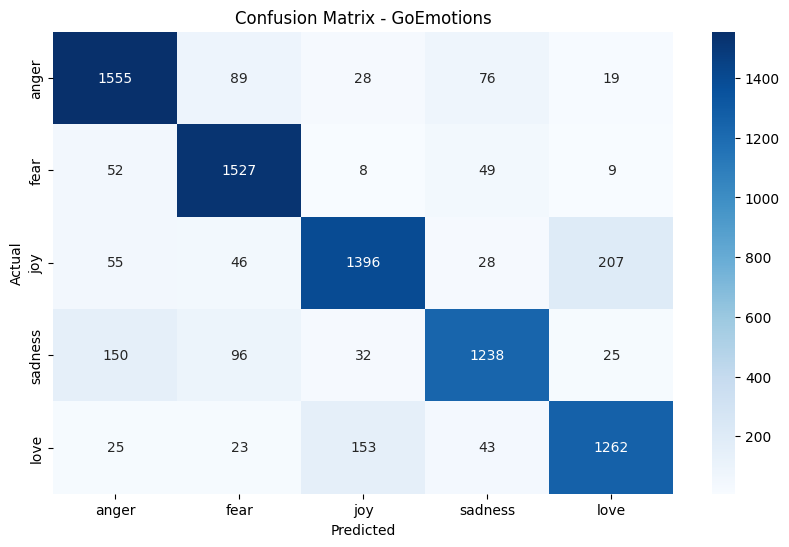

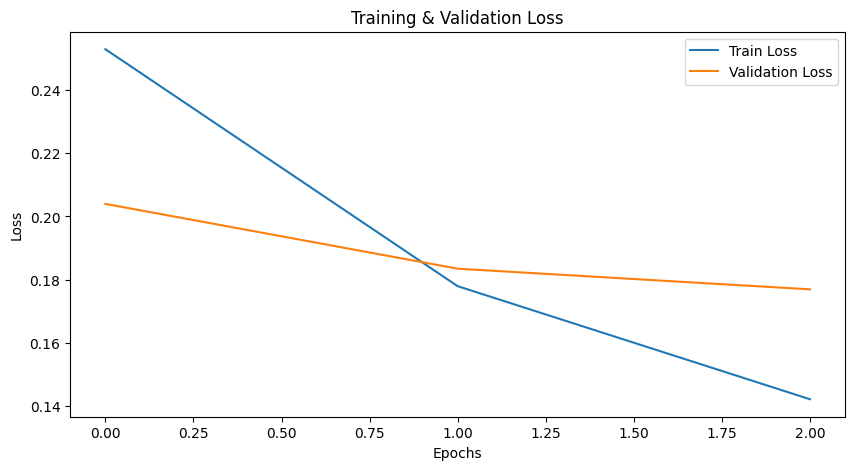

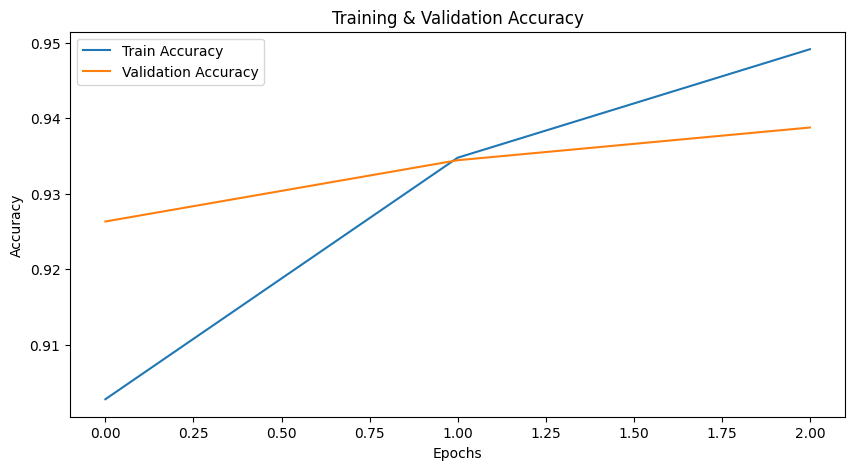


✅ **Training Complete & Final Results Saved!** 🚀


In [14]:
# Move model to evaluation mode
model.eval()

# ✅ Collect Predictions & True Labels
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # Convert logits to probabilities and apply threshold for multi-label classification
        preds = torch.sigmoid(logits) > 0.5

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

# Convert lists to numpy arrays
y_pred = np.vstack(all_preds)
y_true = np.vstack(all_labels)

# ✅ Compute Accuracy & F1 Scores
accuracy = accuracy_score(y_true, y_pred)
f1_micro = f1_score(y_true, y_pred, average="micro")
f1_macro = f1_score(y_true, y_pred, average="macro")

print(f"\n📊 **Final Evaluation Results**")
print(f"✅ Accuracy: {accuracy:.4f}")
print(f"✅ F1-Score (Micro): {f1_micro:.4f}")
print(f"✅ F1-Score (Macro): {f1_macro:.4f}\n")

# ✅ Classification Report
# ✅ Classification Report
print("\n📊 **Classification Report:**")
print(classification_report(y_true, y_pred, target_names=emotions, digits=4))

# Confusion Matrix
plt.figure(figsize=(10, 6))
cm = confusion_matrix(y_true.argmax(axis=1), y_pred.argmax(axis=1))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=emotions, yticklabels=emotions)
plt.title("Confusion Matrix - GoEmotions")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Training & Validation Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

# Training & Validation Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.show()

print("\n✅ **Training Complete & Final Results Saved!** 🚀")

In [16]:
torch.save(model.state_dict(), "/content/drive/MyDrive/EmotionCompanion/models/Final_5_emotions_GoEmotion_model.pth")
print("GoEmotion model saved successfully!")

GoEmotion model saved successfully!
